# Introduction and Theory

### Metropolis Algorithm

- corner stone of the Monte Carlo method, often need to calculate the average of the physical quantity <f> across a system with a specifc probability distribution p(x).

- standard uniform sampling is inefficient for complex systems because points may fall in regions where p(x) is converging so Metropolis algorithm solves this issue using importance sampling.

- what the algorithm does is instead of picking points blindly across a sample space it constructs a random walk that passes through more important regions meaning in these regions the probability distribution is higher.

- goal of the algorithm is to create a sequence of states {$x_0, x_1, ....$} so for a large number of steps the distribution of states will converge to the desired probability density of p(x).

- in order for the algorithm to work we need to keep count of the Condition of Detailed Balance(meaning that the probability of transitioning from state i to state j = probability of transitioning from state j to state i when we weight their equilibrium probabilities) 

- system reaches and equilibrium when the relative probability of being in state $x_i$ versus state $x_j$ remains constant

$$
    p(x_i) T(x_i -> x_j) = p(x_j) T(x_j -> x_i)

\newline

    \frac{p(x_i)}{p(x_j)} = \frac{T(x_j -> x_i)}{T(x_i -> x_j)}
$$

$\qquad$  where T is the transition probability

- T is not unique, simple choice $T(x_i -> x_j) = min(1,  \frac{p(x_j)}{p(x_i)})$ where $\frac{p(x_j)}{p(x_i)}$ is between 0 and 1

- going back to the choice of T we have two cases:

1) if state $x_j$ is more probable than $x_i$ then $p(x_j) > p(x_i)$, move being accepted

2) if the state $x_j$ is less probable than $x_i$ then the move will be accepted with the probability equal to the ratio from before $\frac{p(x_j)}{p(x_i)}$ 

#### Algorithm Implementation 

- algorithm for step $x_i -> x_{i+1}$

1) choose a new trial position $x_{trial} = x_i + \delta_i$ where $\delta_i \in [-\delta, \delta]$ random nr

2) calculate $w = \frac{p(x_{trial})}{p(x_i)}$

3) $w \geq 1$ accept the trial point $x_{i+1} = x_{trial}$

4) $w \le 1$ generate a random number $r \in (0,1)$

5) $w \geq r$ accept the trial point $x_{x+1} = x_{trial}$

6) if not accepted $x_{i+1} = x_i$


- if $\delta$ is too large, only a small percentage of trial are usually accepted => inefficient

- if $\delta$ is too small, many steps are accepted, but samping of p(x) is inefficient




#### Application to the Double-Well Potential

- The goal of this project is to apply the Metropolis algorithm to sample a 1D target distribution representing a physical system, defined as $\pi(x) \propto e^{-\beta U(x)}$, where $\beta = 1/T$ and $T$ is the temperature. The system is characterized by a double-well potential given by $U(x) = x^4 - x^2$ (in units where $k_B = 1$).

- By substituting the potential into the acceptance ratio, the Metropolis acceptance probability becomes $P_{acc} = \min(1, \exp[-\beta(U(x_{trial}) - U(x_i))])$. The proposal distribution is symmetric because the random step $\delta_i$ is chosen from a uniform distribution in the range $[-\Delta, \Delta]$. Because of this symmetry, the condition of detailed balance holds.


# Numerical Methods

##### Verification of the Sampled

- The algorithm will be run at three different suggested temperatures: $T \in \{1.0, 0.5, 0.2\}$ using a chain length of $10^6$ steps. To verify the method, the sampled distribution $\hat{\pi}(x)$ will be estimated using a histogram of the generated samples. The initial data points are discarded to remove initialization effects.

The histogram will be compared to a theoretical reference curve, calculated by evaluating $e^{-\beta U(x)}$ on a grid and normalizing it using numerical quadrature over a wide interval:$$\pi_{ref}(x) = \frac{e^{-\beta U(x)}}{\int_{-\infty}^{\infty} e^{-\beta U(x)} dx}$$

##### Tuning the Proposal Step Size ($\Delta$)

- The choice of the maximum step size $\Delta$ dictates the efficiency of the sampling. As a rule of thumb, $\Delta$ should be tuned so that 1/3 to 1/2 of the trials are accepted. $\Delta$ will be scanned over a logarithmically spaced range of values to study its effect on the acceptance rate. An "optimal" $\Delta$ will be chosen for each temperature by balancing the acceptance rate and the exploration of the state space.

##### Mixing, Metastability, and Barrier Crossing

- To analyze how often the system transitions between the two potential wells, a "well index" will be defined as $w_t = \text{sign}(x_t) \in \{-1, +1\}$. The rate of switching between the wells will be estimated for each temperature, and the distribution of first passage times to change signs will be computed for different starting positions ($x_0 > 0$ versus $x_0 < 0$). This analysis will highlight the issue of metastability at low temperatures, where the chain might appear stationary and mix poorly.

##### Mean Squared Jump Distance (MSJD)

- To further justify the choice of the optimal $\Delta$, the mean squared jump distance will be calculated across the $\Delta$ grid for each temperature. MSJD is defined as $MSJD = \langle (x_{t+1} - x_t)^2 \rangle$, where the average $\langle \cdot \rangle$ is approximated by taking a time average over the recorded series.

##### Convergence Diagnosis

- To ensure the algorithm successfully reaches the equilibrium distribution, two independent Markov chains will be run at a low temperature ($T = 0.2$) using the exact same optimized $\Delta$. Chain A will start in the left well ($x_0 = -1$) and Chain B will start in the right well ($x_0 = +1$). By comparing the histograms of both chains after applying the same burn-in period, we can diagnose whether both chains have converged to the exact same target distribution.







In [1]:
#code for a) Metropolis algorithm

import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson
import math

def potential_function(x):
    return x**4 - x**2

def metropolis_algorithm(n_steps, T, delta, x_0):
    position_array = np.zeros(n_steps)
    beta = 1/T
    position_array[0] = x_0
    accepted_moves = 0

    for i in range(1, n_steps):
        x_current = position_array[i-1]

        step = np.random.uniform(-delta, delta)
        x_trial = x_current + step

        energy_difference = potential_function(x_trial) - potential_function(x_current)
        P_acc = min(1, np.exp(-beta * energy_difference))
        r = np.random.rand()

        if r <= P_acc:
            position_array[i] = x_trial
            accepted_moves += 1
        else:
            position_array[i] = x_current

    acceptance_rate = accepted_moves / n_steps
    return position_array, acceptance_rate

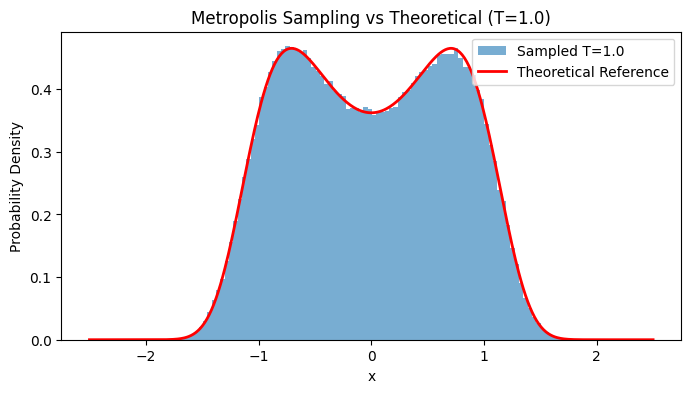

Acceptance Rate: 0.564


In [8]:
#code for b)Verify Distribution

from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt


n_steps = 10**6
T = 1.0
beta = 1.0 /T
delta = 2.0
x_0 = 0.0

raw_chain, acceptance_rate = metropolis_algorithm(n_steps, T, delta, x_0)

burn_in = 10000
chain = raw_chain[burn_in:]

plt.figure(figsize=(8, 4))
plt.hist(chain, bins=100, density=True, alpha=0.6, label=f"Sampled T={T}")

def unnormalized_dist(x):
    return np.exp(-beta * potential_function(x))

Z, error = quad(unnormalized_dist, -5, 5)
x_grid = np.linspace(-2.5, 2.5, 500)
pi_ref = unnormalized_dist(x_grid) / Z

plt.plot(x_grid, pi_ref, 'r-', linewidth=2, label="Theoretical Reference")
plt.title(f"Metropolis Sampling vs Theoretical (T={T})")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

print(f"Acceptance Rate: {acceptance_rate:.3f}")




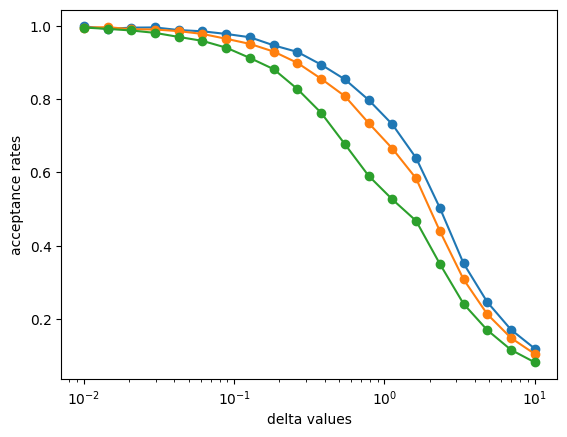

In [15]:
#code for c)Tune Step Size

import numpy as np
import matplotlib.pyplot as plt

delta_values = np.logspace(-2, 1, 20)
steps = 50000
T_values = [1.0, 0.5, 0.2]
accept_rates_T = []

for i in T_values:
    rates_T = []
    for j in delta_values:
        k, acceptance_rate = metropolis_algorithm(steps, i, j, 0.0)
        rates_T.append(acceptance_rate)

    accept_rates_T.append(rates_T)

for idx, l in enumerate(T_values):
    plt.plot(delta_values, accept_rates_T[idx], marker='o', label=f"T = {i}")


    
  

#plt.plot(T_values)
plt.xscale('log')
plt.xlabel("delta values")
plt.ylabel("acceptance rates")  

plt.show()  


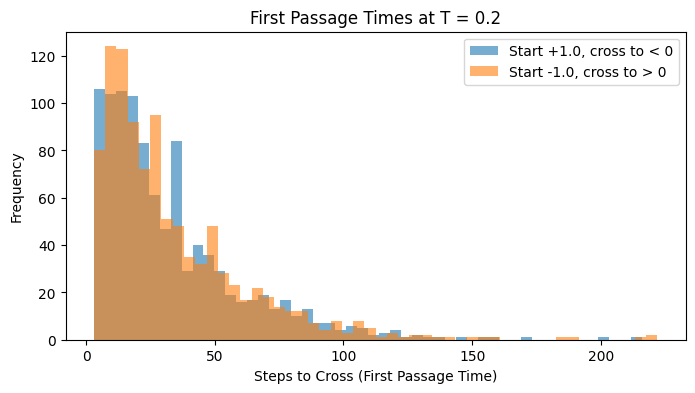

In [ ]:
#code for d) Mixing, metastability, and barrier crossing

import numpy as np
import matplotlib.pyplot as plt

def get_passage_times(num_chains, max_steps, T, delta, start_x, cross_direction):
    times = []
    beta = 1.0 / T
    
    for _ in range(num_chains):
        x = start_x
        for i in range(1, max_steps):
            
            step = np.random.uniform(-delta, delta)
            x_trial = x + step
            
            dU = (x_trial**4 - x_trial**2) - (x**4 - x**2)
            if np.random.rand() <= np.exp(-beta * dU):
                x = x_trial
            
           
            if (cross_direction == 'left' and x < 0) or \
               (cross_direction == 'right' and x > 0):
                times.append(i)
                break 
                
    return times


optimal_delta = 0.5 
num_sims = 1000
max_allowed_steps = 100000 


times_to_left = get_passage_times(num_sims, max_allowed_steps, 0.2, optimal_delta, 1.0, 'left')
times_to_right = get_passage_times(num_sims, max_allowed_steps, 0.2, optimal_delta, -1.0, 'right')


plt.figure(figsize=(8, 4))
plt.hist(times_to_left, bins=50, alpha=0.6, label='Start +1.0, cross to < 0')
plt.hist(times_to_right, bins=50, alpha=0.6, label='Start -1.0, cross to > 0')
plt.xlabel('Steps to Cross (First Passage Time)')
plt.ylabel('Frequency')
plt.title('First Passage Times at T = 0.2')
plt.legend()
plt.show()

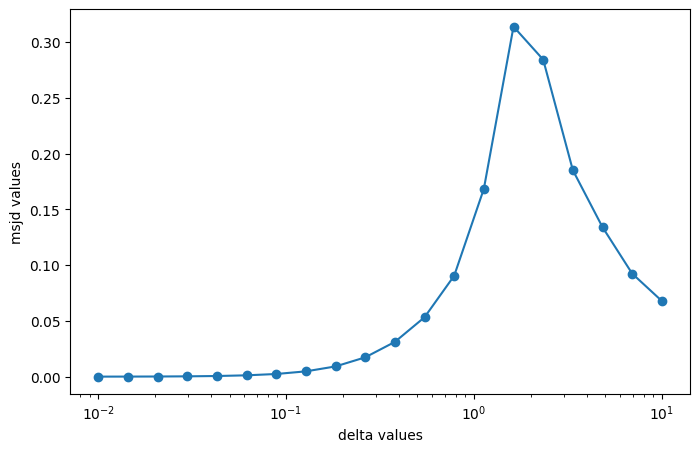

In [19]:
#code for e)Mean Squared Jump Distance (MSJD)

import numpy as np
import matplotlib.pyplot as plt

delta_values = np.logspace(-2, 1, 20)
steps_scan = 50000  
burn_in = 5000      
T_values = [1.0, 0.5, 0.2]

plt.figure(figsize=(8,5))

for T in T_values:
    msjd_T = []
    for j in delta_values:
            raw_chain, k = metropolis_algorithm(steps, i, j, 0.0)
            chain = raw_chain[burn_in:]
            msjd = np.mean(np.diff(chain) **2)
            msjd_T.append(msjd)

plt.plot(delta_values, msjd_T, marker='o', label=f"T = {T}")




plt.xscale('log')
plt.xlabel("delta values")
plt.ylabel("msjd values")  

plt.show()  

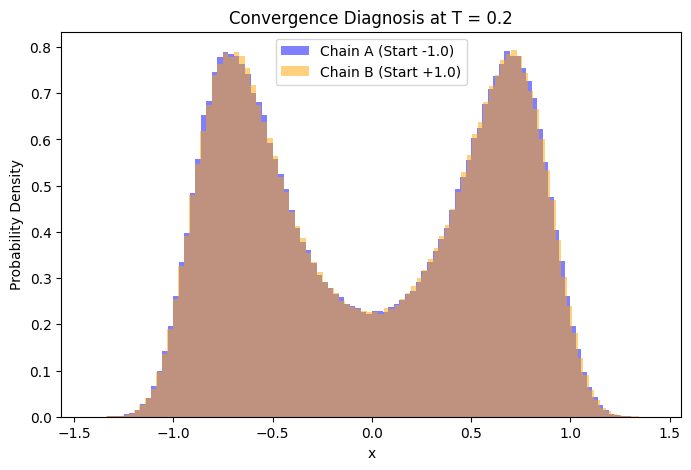

In [20]:
#code for f) Convergence diagnosis using two chains

import numpy as np
import matplotlib.pyplot as plt


n_steps = 10**6
T = 0.2
burn_in = 10000


optimal_delta = 0.5 


raw_chain_A, _ = metropolis_algorithm(n_steps, T, optimal_delta, -1.0)
raw_chain_B, _ = metropolis_algorithm(n_steps, T, optimal_delta, 1.0)

chain_A = raw_chain_A[burn_in:]
chain_B = raw_chain_B[burn_in:]


plt.figure(figsize=(8, 5))
plt.hist(chain_A, bins=100, density=True, alpha=0.5, label='Chain A (Start -1.0)', color='blue')
plt.hist(chain_B, bins=100, density=True, alpha=0.5, label='Chain B (Start +1.0)', color='orange')

plt.title('Convergence Diagnosis at T = 0.2')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()